\newpage

# <span style="color: #d9534f;"> Setup, Import, and Data Cleaning </span>

Data was imported using pandas 'read_excel'.

In [14]:
#| echo: false
#| output: false
# Import libraries.
import os

import pandas as pd

print(f"Pandas version: {pd.__version__}")

import numpy as np
print(f"Numpy version: {np.__version__}")

import openpyxl
print(f"Openpyxl version: {openpyxl.__version__}")

# When importing a sub-module so we don't do version checking on it directly.
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# For more plot options.
import seaborn as sns

# For data validation.
import pandera.pandas as pa

# For statistical tests.
from scipy import stats
import statsmodels.api as sm

Pandas version: 2.3.3
Numpy version: 2.2.6
Openpyxl version: 3.1.5


In [2]:
#| echo: false
#| output: false
'''
We will want to import the schema used for 'PUFYEAR','OPTIME',
 'AGE', and 'SEX', as well as the 'check_data' function we used
 to get a printout of how many rows have column values that don't
 match the schema.
'''
from utilities import base_schema, check_data

In [3]:
#| echo: false
#| output: false
# Set some options for pandas so that it doesn't truncate the dataframe
#   view window.
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

In [4]:
#| echo: false
#| output: false
# Import the raw data.
file_path = os.path.join('..', 'Data', 'Module 2 - NSQIP_83083_OPTIME by PUFYEAR, SEX.xlsx')
raw_df = pd.read_excel(file_path)

In [5]:
#| echo: false
#| output: false

# Create a copy of the raw data.
df = raw_df.copy()

In [6]:
#| echo: false
#| output: false

# Create a binary variable for SEPSIS: 0 for "None" and 1 for any other values.
df.loc[:, 'SEPSIS'] = df['PRSEPIS'].notna().astype(int)

# NaN values replaced with 0 in 'BLEEDIS' column.
df.loc[:, 'BLEEDIS'] = df['BLEEDIS'].fillna(0).astype(int)

# Drop BMI = NaN rows.
df = df.dropna(subset=['BMI'])

# We create the Comorbidities Count column.
# Define the 17 comorbidity columns
comorbidity_columns = [
    'DIABETES', 'SMOKE', 'DYSPNEA', 'VENTILAT', 'HXCOPD', 'ASCITES',
    'HXCHF', 'HYPERMED', 'RENAFAIL', 'DIALYSIS', 'DISCANCR', 'WNDINF',
    'STEROID', 'WTLOSS', 'BLEEDIS', 'TRANSFUS', 'SEPSIS'
]

# Create COMORBIDITIES with binning (cap at 3)
df.loc[:, 'COMORBIDITIES'] = df[comorbidity_columns].sum(axis=1).clip(upper=3)


# Looking ahead, I'm going to make one column for the actual counts, recoding as integer values (there was a single float typed value).
#   and one for the categorical mapping.
df.loc[:, 'COMORBIDITIES COUNT'] = (
    df[comorbidity_columns].sum(axis=1)
    #.clip(upper=3)
    .astype(int)
    #.map({0: '0', 1: '1', 2: '2', 3: '3+'})
    #.astype('category')
)

# First convert to numeric (float) values, where the upper cap at 3 is for 3+.
# We can convert to categorical with a map.
df.loc[:, 'COMORBIDITIES CAT'] = (
    df[comorbidity_columns].sum(axis=1)
    .clip(upper=3)
    .astype(int)
    .map({0: '0', 1: '1', 2: '2', 3: '3+'})
    .astype('category')
)

# Keeping 'TOTHLOS' here as well, per the Exercise steps.
# This is 'total length of stay' in days.', so we expect most to be zero.
# Added 'HEIGHT' as a keep column here for the assignment.
keep_columns = ['PUFYEAR', 'AGE', 'SEX', 'BMI', 'OPTIME', 'HEIGHT',
                'COMORBIDITIES COUNT', 'COMORBIDITIES CAT']

# Drop 'AGE' values that are set to NaN / None and drop any 'OPTIME' values which are NaN or not in the correct range.
# Added logic here to make sure the 'HEIGHT' variables aren't NaN / None.
df_clean = df.query(
    "OPTIME != 0 and OPTIME != -99 and OPTIME == OPTIME "
    "and AGE == AGE "
    "and HEIGHT == HEIGHT"
)[keep_columns].copy()

# There were still some NaN values hiding in the 'OPTIME' column.


# Print final row/column count.
df_clean.shape

(82072, 8)

In [7]:
#| echo: false
#| output: false

# Output hidden due to dataframe width.
display(df_clean.head(3))

,PUFYEAR,AGE,SEX,BMI,OPTIME,HEIGHT,COMORBIDITIES COUNT,COMORBIDITIES CAT
0,2014,25.0,male,26.548571,120.0,70.0,1,1
1,2014,31.0,male,24.528571,95.0,70.0,0,0
2,2014,27.0,male,30.153739,66.0,71.0,0,0


In [8]:
#| echo: false
#| output: false

# We'll want to double check the remaining 'HEIGHT' values just in case.
exercise4_schema = pa.DataFrameSchema({
    "OPTIME": pa.Column(int, checks=pa.Check.greater_than(0), nullable=False, coerce=True),
    "AGE": pa.Column(float, checks=pa.Check.in_range(0, 120), nullable=False),
    "BMI": pa.Column(float, checks=pa.Check.in_range(10, 150), nullable=False),
    "HEIGHT": pa.Column(float, checks=pa.Check.in_range(48, 96), nullable=False),
})

check_data(df_clean, exercise4_schema)

Summary of Validation Errors:


,column,check,failure_case,count
5,HEIGHT,"in_range(48, 96)",41.000000,4
0,BMI,"in_range(10, 150)",9.546682,1
1,BMI,"in_range(10, 150)",9.632569,1
2,BMI,"in_range(10, 150)",9.900597,1
3,BMI,"in_range(10, 150)",9.955826,1
4,HEIGHT,"in_range(48, 96)",40.000000,1
6,HEIGHT,"in_range(48, 96)",44.000000,1
7,HEIGHT,"in_range(48, 96)",46.000000,1


In [11]:
#| echo: false
#| output: false

# I'm going to look at these height outliers to see if maybe they're children.

df_clean[df_clean['HEIGHT'] < 48][['AGE', 'HEIGHT', 'BMI', 'OPTIME']]

# Well, they're not children, but I suppose it's possible they're little persons.
# I asked Claude, and it said that for the ages and BMI values it maybe consistent with achondroplasia.
# Since we've never had any instruction to remove these rows (that I remember) I'm just going to assume they're not a data entry error and move on.

,AGE,HEIGHT,BMI,OPTIME
12199,70.0,41.0,65.190363,17.0
28599,67.0,40.0,26.512500,33.0
28600,48.0,41.0,59.302201,25.0
28601,50.0,41.0,74.022606,42.0
28602,45.0,46.0,58.471172,22.0
70190,29.0,41.0,63.087448,97.0
70191,36.0,44.0,134.023244,90.0


We took the following steps:

- Created the 'PRSEPIS' column by using the values in 'SEPSIS', coding any value not equal to 1 as 0.
- Recoded the 'BLEEDIS' column values from NaN / None / Empty to zeros.
- Dropped any rows with NaN values in the 'BMI' column.
- Created the 'COMORBIDITIES COUNT' column by summing the values in the comorbidity columns.
- Created the 'COMORBIDITIES CAT' column by recoding the 'COMORBIDITIES COUNT' column as integers, with the upper cap at 3.
- Dropped rows for any values for 'OPTIME' that were zero, NaN, or '-99.'
- Dropped any values of 'AGE' that were NaN / None.
- Dropped any values of 'HEIGHT' that were NaN / None.

We ended up with 82,072 rows and 8 columns.

\newpage

# Exercise 4 - Results

## Graphs: OPTIME by AGE

N          = 82,072
Intercept  = 98.5115
Slope      = -1.1199
R²         = 0.1615
p-value    = < .0001

Equation: OPTIME = 98.5115 + (-1.1199 × AGE)
Interpretation: For every 1-year increase in AGE, OPTIME changes by -1.12 minutes.


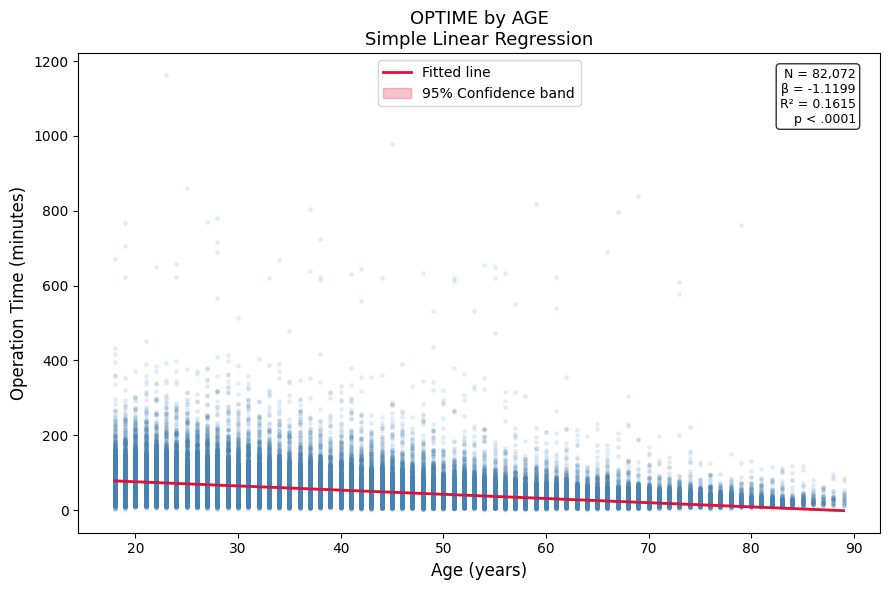

In [26]:
#| echo: false

x = df_clean['AGE'].values
y = df_clean['OPTIME'].values
n = len(x)

# --- Fit regression ---
X = sm.add_constant(x)
model = sm.OLS(y, X).fit()

intercept, slope = model.params
r_squared = model.rsquared
p_value = model.pvalues[1]

print(f"N          = {n:,}")
print(f"Intercept  = {intercept:.4f}")
print(f"Slope      = {slope:.4f}")
print(f"R²         = {r_squared:.4f}")
print(f"p-value    = {'< .0001' if p_value < .0001 else f'{p_value:.4f}'}")

print(f"\nEquation: OPTIME = {intercept:.4f} + ({slope:.4f} × AGE)")
print(f"Interpretation: For every 1-year increase in AGE, OPTIME changes by {slope:.2f} minutes.")

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 6))

x_range = np.linspace(x.min(), x.max(), 300)
X_range = sm.add_constant(x_range)
predictions = model.get_prediction(X_range)
pred_df = predictions.summary_frame(alpha=0.05)

ax.scatter(x, y, alpha=0.1, s=6, color='steelblue', rasterized=True)
ax.plot(x_range, pred_df['mean'], color='crimson', lw=2, label='Fitted line')
ax.fill_between(x_range, pred_df['mean_ci_lower'], pred_df['mean_ci_upper'],
                alpha=0.25, color='crimson', label='95% Confidence band')

ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Operation Time (minutes)', fontsize=12)
ax.set_title('OPTIME by AGE\nSimple Linear Regression', fontsize=13)
ax.legend(fontsize=10)

stats_text = (
    f"N = {n:,}\n"
    f"β = {slope:.4f}\n"
    f"R² = {r_squared:.4f}\n"
    f"p < .0001"
)
ax.text(0.97, 0.97, stats_text, transform=ax.transAxes,
        fontsize=9, va='top', ha='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

\newpage

## Graphs: OPTIME by HEIGHT

N          = 82,072
Intercept  = -15.8910
Slope      = 0.9130
R²         = 0.0076
p-value    = < .0001

Equation: OPTIME = -15.8910 + (0.9130 × HEIGHT)
Interpretation: For every 1-inch increase in HEIGHT, OPTIME changes by 0.91 minutes.


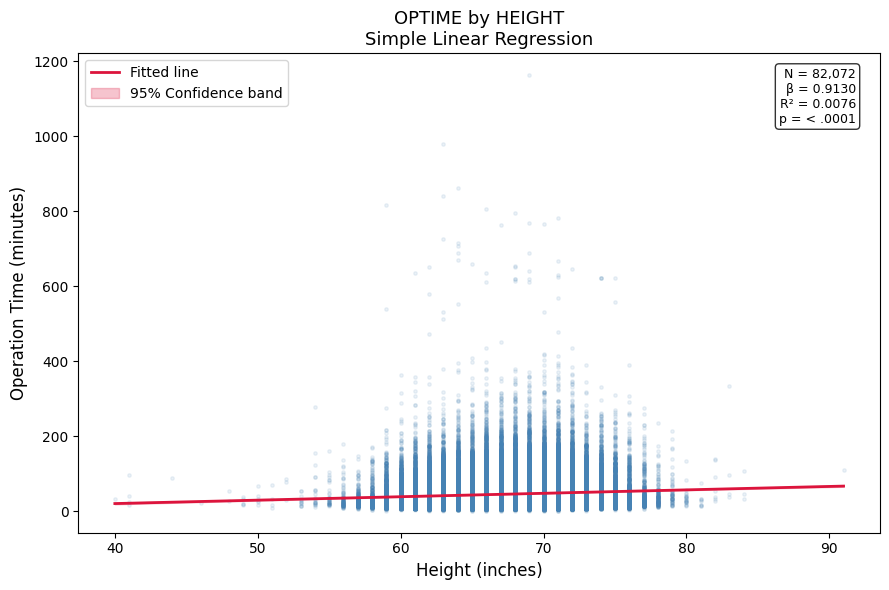

In [27]:
#| echo: false

x = df_clean['HEIGHT'].values
y = df_clean['OPTIME'].values
n = len(x)

# --- Fit regression ---
X = sm.add_constant(x)
model = sm.OLS(y, X).fit()

intercept, slope = model.params
r_squared = model.rsquared
p_value = model.pvalues[1]

print(f"N          = {n:,}")
print(f"Intercept  = {intercept:.4f}")
print(f"Slope      = {slope:.4f}")
print(f"R²         = {r_squared:.4f}")
print(f"p-value    = {'< .0001' if p_value < .0001 else f'{p_value:.4f}'}")

print(f"\nEquation: OPTIME = {intercept:.4f} + ({slope:.4f} × HEIGHT)")
print(f"Interpretation: For every 1-inch increase in HEIGHT, OPTIME changes by {slope:.2f} minutes.")

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 6))

x_range = np.linspace(x.min(), x.max(), 300)
X_range = sm.add_constant(x_range)
predictions = model.get_prediction(X_range)
pred_df = predictions.summary_frame(alpha=0.05)

ax.scatter(x, y, alpha=0.1, s=6, color='steelblue', rasterized=True)
ax.plot(x_range, pred_df['mean'], color='crimson', lw=2, label='Fitted line')
ax.fill_between(x_range, pred_df['mean_ci_lower'], pred_df['mean_ci_upper'],
                alpha=0.25, color='crimson', label='95% Confidence band')

ax.set_xlabel('Height (inches)', fontsize=12)
ax.set_ylabel('Operation Time (minutes)', fontsize=12)
ax.set_title('OPTIME by HEIGHT\nSimple Linear Regression', fontsize=13)
ax.legend(fontsize=10)

stats_text = (
    f"N = {n:,}\n"
    f"β = {slope:.4f}\n"
    f"R² = {r_squared:.4f}\n"
    f"p = {'< .0001' if p_value < .0001 else f'{p_value:.4f}'}"
)
ax.text(0.97, 0.97, stats_text, transform=ax.transAxes,
        fontsize=9, va='top', ha='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

\newpage

# Exercise 4 - Summaries: OPTIME by AGE

## Journal Summary

A simple linear regression was conducted to examine the predictive power of patient age on operation time (OPTIME) in a sample of $N = 82,072$ patients from the NSQIP dataset. The model was statistically significant $(\beta = −1.12, p < .0001)$, indicating that for every one-year increase in patient age, operationk time decreases by approximately 1.12 minutes.

The regression equation was $\text{OPTIME} = 98.51 + (−1.12 \times \text{AGE} )$. The model explained $16.15\%$ of the variance in operation time $(R^2 = 0.1615)$. OPTIME is right-skewed with notable outliers, which may violate the homoscedasticity assumption of OLS regression; the large sample size mitigates this to some degree. Age alone is an incomplete predictor of surgical duration, as the majority of variance remains unexplained.

## Stakeholder Summary

We wanted to understand whether a patient's age could help predict how long their surgery would take. Using data from over 82,000 surgical cases, we found that older patients tend to have slightly shorter surgeries — roughly one minute less for each additional year of age.

While this pattern is statistically reliable, age alone explains only about $16\%$ of the differences in surgery length, meaning many other factors also play a role. One limitation is that surgery time is highly variable across patients, which reduces the precision of any single-predictor model.

\newpage

# Exercise 4 - Summaries: OPTIME by HEIGHT

## Journal Summary

A simple linear regression was conducted to examine the predictive power of patient height on operation time (OPTIME) in a sample of $N = 82,072$ patients from the NSQIP dataset. The model was statistically significant $(\beta = 0.91, p < .0001)$, indicating that for every one-inch increase in height, operation time increases by approximately $0.91$ minutes.

The regression equation was $\text{OPTIME} = −15.89 + (0.91 \times \text{HEIGHT})$. However, the model explained less than $1\%$ of the variance in operation time $(R^2 = 0.0076)$, indicating that height has negligible practical predictive power despite the statistically significant result. The large sample size increases statistical power to detect even trivially small effects, and the right-skewed distribution of OPTIME may violate homoscedasticity assumptions.


## Stakeholder Summary

We examined whether a patient's height could help predict how long their surgery would take. While we did find a small statistically detectable tendency for taller patients to have slightly longer surgeries, height explains less than $1\%$ of the differences in surgery length across patients. This makes it essentially useless as a standalone predictor for scheduling or staffing purposes.

One limitation is that with over $82,000$ cases, even trivially small relationships will appear statistically significant, so practical significance must be considered alongside statistical results.
